# Resultados del experimento HA2

**MISW4202 · Grupo 12, Solventa**

Este cuaderno reúne, sobre el mismo registro (`resultados/adaptador.jsonl`) y el mismo motor (`analisis.procesamiento`), el análisis realizado hasta ahora:

- Disponibilidad, conmutación y latencia en A, B, C y G.
- El costo de disparar el corte frente a encontrar el circuito ya abierto, en B, C y D.
- Recuperación del circuit breaker en E.

## Resumen

Se procesaron las 27.533 peticiones registradas (7 escenarios × 3 corridas) y se calcularon las métricas del ASR HA2 para los escenarios **A** (baseline), **B** (lentitud), **C** (caída total) y **G** (concurrencia).

**Las dos metas se cumplen en los cuatro escenarios.** La disponibilidad fue del 100 % en todos, sin una sola petición fallida en 18.217. En B y C, donde el proveedor se degrada y el circuito llega a abrirse, el 100 % de las conmutaciones ocurrió por debajo de 1 s; la más lenta tardó 6,4 ms.

| | A · Baseline | B · Lentitud | C · Caída total | G · Concurrencia |
|---|---|---|---|---|
| Peticiones | 2.337 | 5.449 | 5.789 | 4.642 |
| Disponibilidad | 100 % | 100 % | 100 % | 100 % |
| Tasa de errores | 0 % | 0 % | 0 % | 0 % |
| Conmutaciones < 1 s | N/A | 100 % | 100 % | N/A |
| Cache hit rate | N/A | 100 % | 100 % | N/A |
| Latencia p50 / p95 | 498 / 647 ms | 0,7 / 75 ms | 0,7 / 1,7 ms | 3.779 / 4.006 ms |

Dos advertencias para leer bien la tabla, y las dos importan:

- **A y G no ejercitan el mecanismo.** Los dos corrieron con el proveedor sano, así que no hubo conmutaciones ni consultas a caché. Sus celdas de conmutación y hit rate salen `N/A` porque el denominador es cero, no porque falte el dato.
- **La latencia de G no mide el circuit breaker.** Los ~4 s son la saturación del proveedor simulado con 50 usuarios en paralelo. En G el circuito nunca se abrió.

## 1. Datos cargados

Para el análisis se cargaron tres fuentes, cada una con un papel distinto:

**`resultados/adaptador.jsonl`** es la fuente principal. Es el registro que escribe el Adaptador, con una fila por petición y las columnas que definimos en el esquema de medición: estado del circuito al inicio y al final, `hit_miss`, `tiempo_conmutacion_ms`, `latencia_total_ms` y el resultado del journey. De aquí salen todas las métricas del ASR: 27.533 peticiones repartidas en 7 escenarios y 3 corridas cada uno.

**Los `results_stats.csv` de Locust** aportan el throughput y la latencia vista desde el cliente. Son agregados por endpoint (dos filas por corrida con conteos y percentiles), así que sirven para medir cuántas peticiones por segundo sostuvo el sistema y para contrastar la latencia externa con la que mide el Adaptador, pero no para las métricas del ASR. Les faltan el estado del circuito, `hit_miss` y `tiempo_conmutacion_ms`, y hay un límite de fondo: para Locust una respuesta del proveedor y una servida desde caché son el mismo HTTP 200, así que no distingue un journey exitoso de uno degradado.

**Los `manifest.json`** registran las condiciones con las que corrió cada escenario: modo del proveedor simulado, usuarios, duración y los parámetros del breaker.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# La raiz del repositorio se localiza buscando la carpeta de datos, para no
# depender de cuantos niveles separan al cuaderno de la raiz.
RAIZ = next(
    padre for padre in [Path.cwd(), *Path.cwd().parents] if (padre / "resultados").is_dir()
)
sys.path.insert(0, str(RAIZ))

from analisis.procesamiento.carga import (
    ESCENARIOS_ENTREGABLE,
    cargar_manifiestos,
    cargar_peticiones,
)
from analisis.procesamiento import metricas

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

SALIDAS = RAIZ / "analisis" / "procesamiento" / "salidas"

carga = cargar_peticiones()
df = carga.peticiones
print(carga.resumen_calidad())

Peticiones cargadas: 27533
Filas descartadas: 0
[incidencia] 9562 peticiones con hit_miss='N/A' (servidas por el proveedor): excluidas del denominador del cache hit rate.
[incidencia] ejecucion_id se repite entre escenarios: se agrupa por (escenario, ejecucion_id).


No se descartó ninguna fila. Las dos incidencias que reporta la carga son ajustes necesarios sobre lo que emite la instrumentación:

- Las 9.562 peticiones servidas por el proveedor llegan con `hit_miss = "N/A"`. Nunca consultaron la caché, así que se dejan fuera del denominador del hit rate; contarlas como miss lo hundiría de forma artificial.
- El `ejecucion_id` (`run1_rep1..3`) se repite en los siete escenarios, de modo que agrupar solo por él mezclaría corridas distintas. La llave es siempre el par `(escenario, ejecucion_id)`.

### Condiciones de cada corrida

Antes de mirar cualquier número conviene revisar qué se probó: el modo del proveedor simulado decide si el mecanismo llegó a activarse.

In [2]:
condiciones = cargar_manifiestos()
condiciones[condiciones.escenario.isin(ESCENARIOS_ENTREGABLE)].drop_duplicates(
    subset=["escenario", "modo_mock", "usuarios", "duracion_s"]
)[["escenario", "modo_mock", "usuarios", "duracion_s", "timeout_ms", "fail_max", "reset_timeout_s", "ttl_s"]]

,escenario,modo_mock,usuarios,duracion_s,timeout_ms,fail_max,reset_timeout_s,ttl_s
0,A,normal,10,60,700,1,10,300
3,B,lento,10,60,700,1,10,300
6,C,caido,10,60,700,1,10,300
18,G,normal,50,120,700,1,10,300


Aquí queda claro por qué A y G se comportan igual: los dos usan `modo=normal`. G se diferencia solo en la carga (50 usuarios durante 120 s frente a 10 durante 60 s), así que mide concurrencia con el proveedor sano, no degradación bajo carga.

## 2. Totales, disponibilidad, errores y hit rate

Estas son las fórmulas que definimos como equipo al diseñar el experimento:

- Disponibilidad = (exitosos + degradados) / total × 100
- Tasa de errores = fallidos / total × 100
- Conmutaciones < 1 s = las que tardaron menos de 1 s ÷ **las que efectivamente conmutaron** × 100
- Cache hit rate = HIT / (HIT + MISS) × 100

In [3]:
resumen = metricas.tabla_resumen(df)
columnas = [
    "escenario", "total_peticiones", "exitosos", "degradados", "fallidos",
    "disponibilidad_pct", "tasa_errores_pct", "peticiones_conmutadas",
    "pct_conmutaciones_bajo_1s", "cache_hit_rate_pct",
    "latencia_p50_ms", "latencia_p95_ms", "latencia_p99_ms", "latencia_max_ms",
]
resumen[resumen.escenario.isin(ESCENARIOS_ENTREGABLE)][columnas].round(2)

,escenario,total_peticiones,exitosos,degradados,fallidos,disponibilidad_pct,tasa_errores_pct,peticiones_conmutadas,pct_conmutaciones_bajo_1s,cache_hit_rate_pct,latencia_p50_ms,latencia_p95_ms,latencia_p99_ms,latencia_max_ms
0,A,2337,2337,0,0,100.0,0.0,0.0,NaN,NaN,498.32,646.50,700.43,772.21
1,B,5449,154,5295,0,100.0,0.0,5295.0,100.0,100.0,0.73,74.80,652.01,712.81
2,C,5789,146,5643,0,100.0,0.0,5643.0,100.0,100.0,0.69,1.69,96.07,179.85
6,G,4642,4642,0,0,100.0,0.0,0.0,NaN,NaN,3779.38,4005.69,4116.82,4291.29


La columna `degradados` muestra dónde actuó el mecanismo: 5.295 peticiones en B y 5.643 en C se respondieron desde Redis en vez de fallar. Esas son las que sostienen el 100 % de disponibilidad, y todas encontraron perfil en caché (hit rate del 100 %).

Sobre el denominador del porcentaje bajo 1 s: son las peticiones que conmutaron, no el total. En A y G no conmutó ninguna, así que la métrica queda indefinida y se reporta `N/A`. Poner 0 % sugeriría que el mecanismo falló y poner 100 % que funcionó; ninguna de las dos cosas pasó, sencillamente no se ejercitó.

## 3. ¿Cuánto tarda una petición?

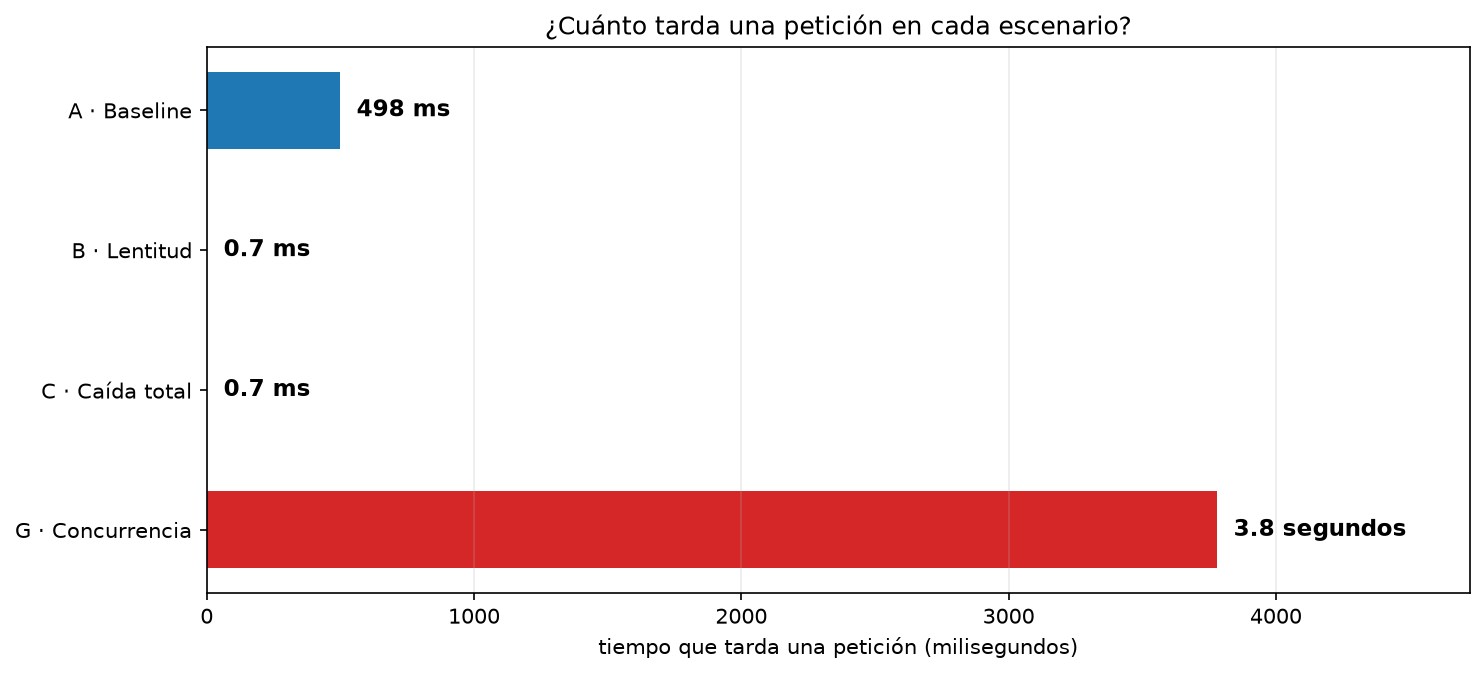

In [4]:
display(Image(filename=str(SALIDAS / "distribucion_latencia.png")))

Cada barra es lo que tarda una petición típica: la mitad de las peticiones fue más rápida y la mitad más lenta.

**A** se sitúa cerca de los 500 ms: es el costo normal de consultar Open Finance. **B y C caen por debajo de 1 ms**, unas 700 veces más rápido, porque con el circuito abierto casi todas las peticiones se resuelven contra Redis sin salir a la red. Sus barras son tan cortas que apenas se ven, y eso es justamente el resultado. Que C quede aún más comprimido que B tiene sentido: en caída total el proveedor rechaza al instante, mientras que en lentitud algunas peticiones alcanzan a esperar el timeout.

**G** está en otra escala, sobre los 3.800 ms. Insistimos en el punto porque es fácil malinterpretarlo: no es el mecanismo siendo lento, es el proveedor simulado saturado con 50 usuarios concurrentes. En G el circuito permaneció cerrado todo el tiempo.

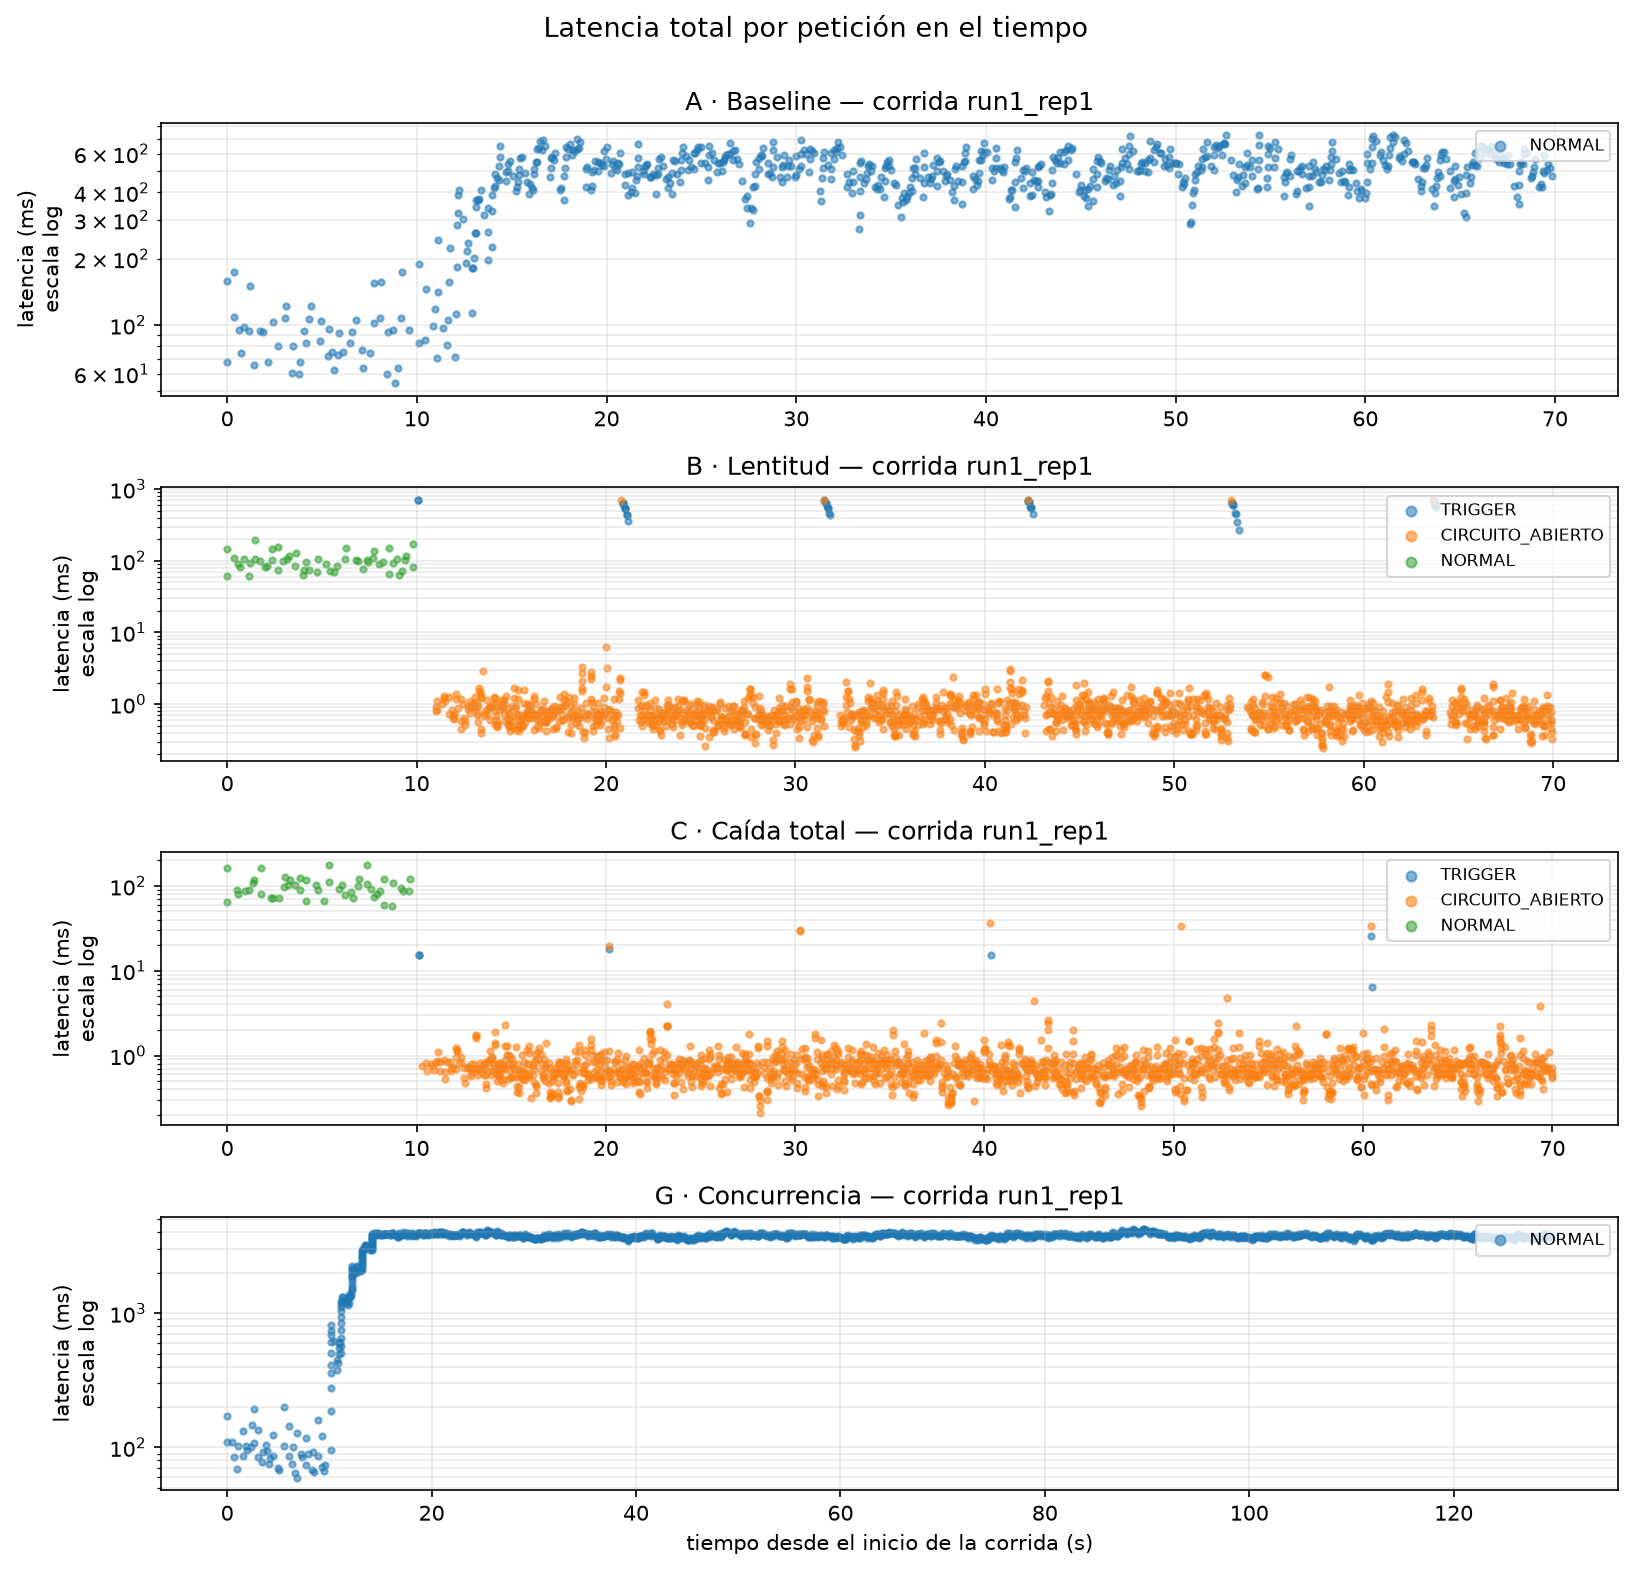

In [5]:
display(Image(filename=str(SALIDAS / "latencia_en_el_tiempo.png")))

Cada punto es una petición a lo largo de una corrida. En **A** y **G** la nube es plana de principio a fin, como corresponde a un proveedor que no cambia de comportamiento.

En **B** y **C** se ve el quiebre: durante los primeros ~10 s las peticiones cuestan unos 100 ms contra el proveedor y, cuando este se degrada, la nube se desploma a la banda de 1 ms. Los puntos sueltos que quedan arriba después del quiebre son los reintentos periódicos del breaker, que vuelve a probar el proveedor cada cierto tiempo.

## 4. Estado del circuito en el tiempo

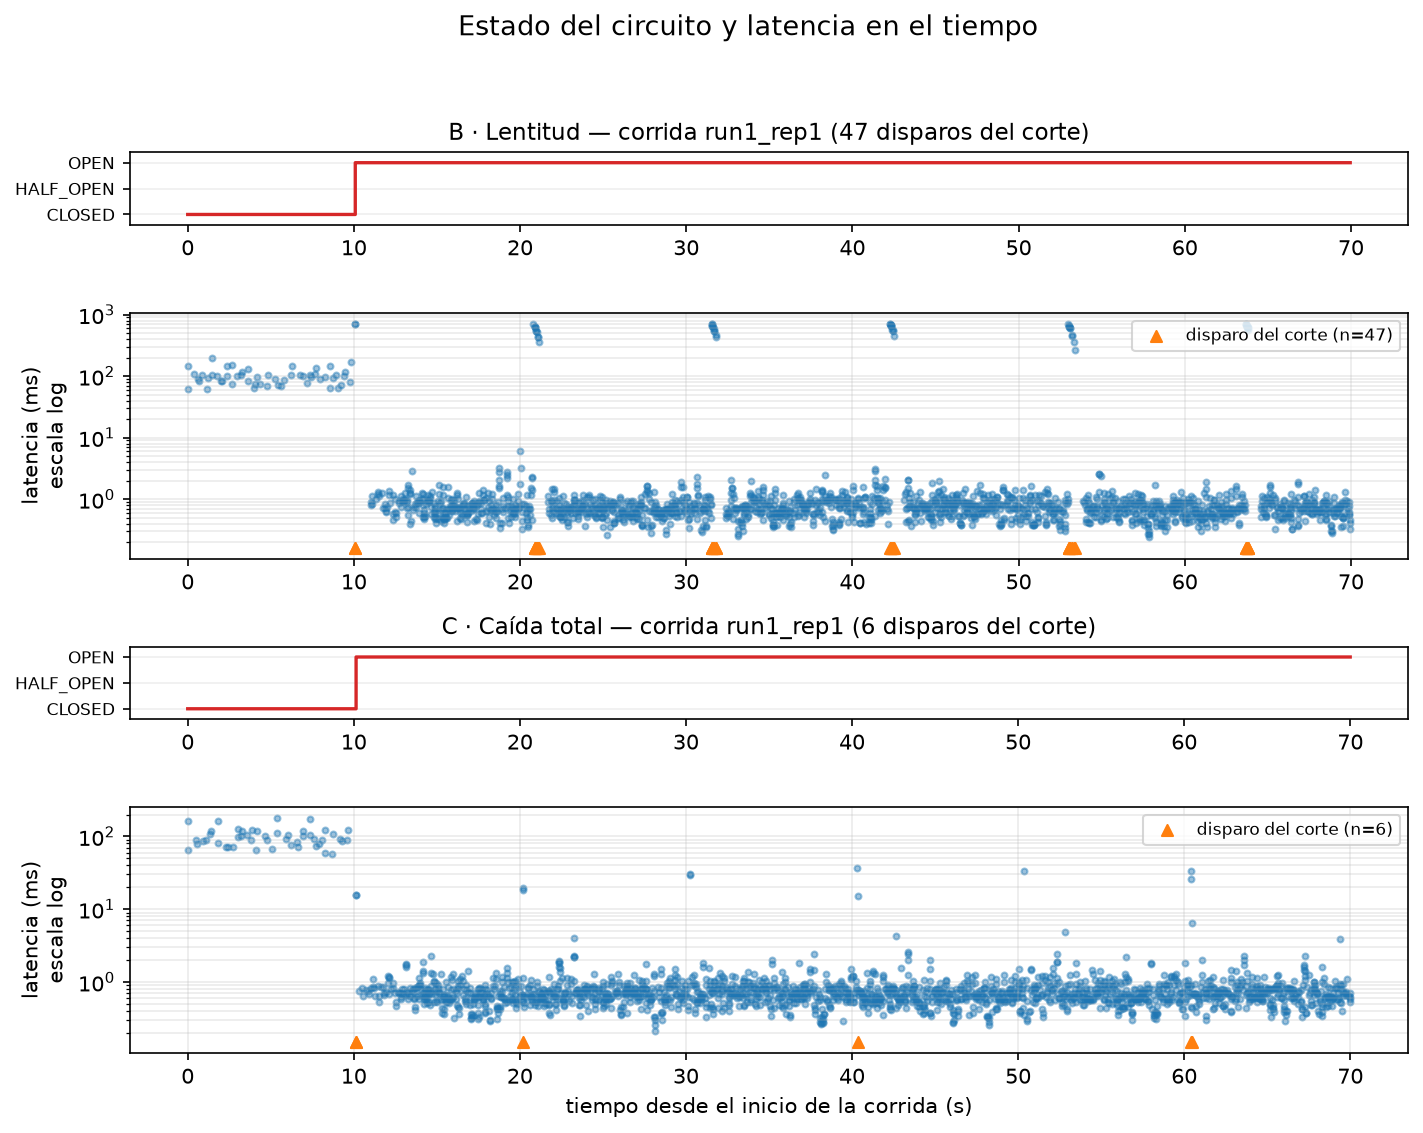

In [6]:
display(Image(filename=str(SALIDAS / "estado_circuito_y_latencia.png")))

Esta es la gráfica que mejor explica el mecanismo. La banda superior de cada escenario es el estado del circuito y el panel de abajo la latencia de cada petición, en escala logarítmica.

Al segundo 10 el proveedor se degrada y el circuito salta de `CLOSED` a `OPEN`. En ese mismo instante la latencia cae dos órdenes de magnitud, de ~100 ms a ~0,7 ms: es el efecto de dejar de esperar al proveedor y responder desde Redis.

Los triángulos naranjas del borde inferior marcan los reintentos. Aparecen cada ~10 s porque `reset_timeout` está en 10 s: el breaker deja pasar una petición de prueba, el proveedor sigue caído y el circuito se reabre. Ese patrón regular es exactamente lo que se espera con `fail_max=1`, y es también la razón de los puntos altos aislados de la gráfica anterior.

B acumula 47 disparos en la corrida frente a 6 de C. La diferencia viene del modo de fallo: en lentitud cada reintento gasta el timeout completo antes de fallar, mientras que en caída total el proveedor rechaza de inmediato.

## 5. Cumplimiento de las metas

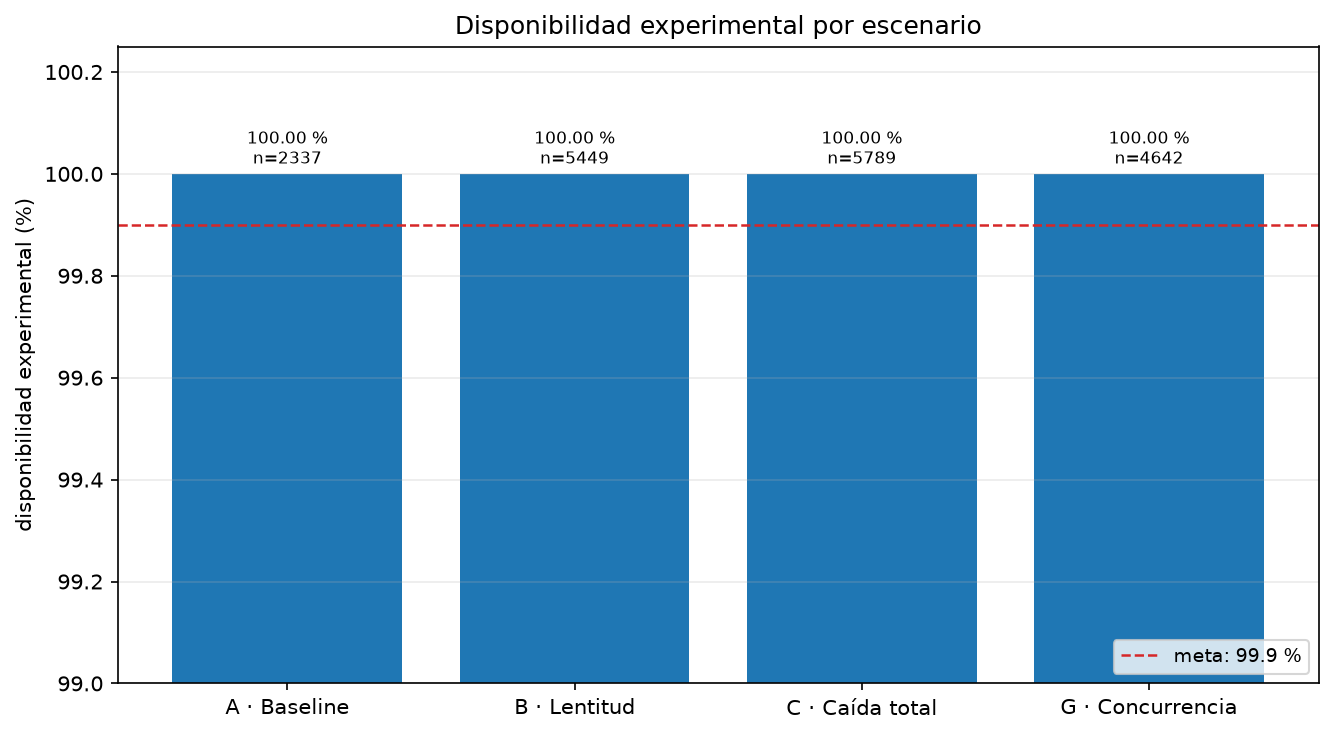

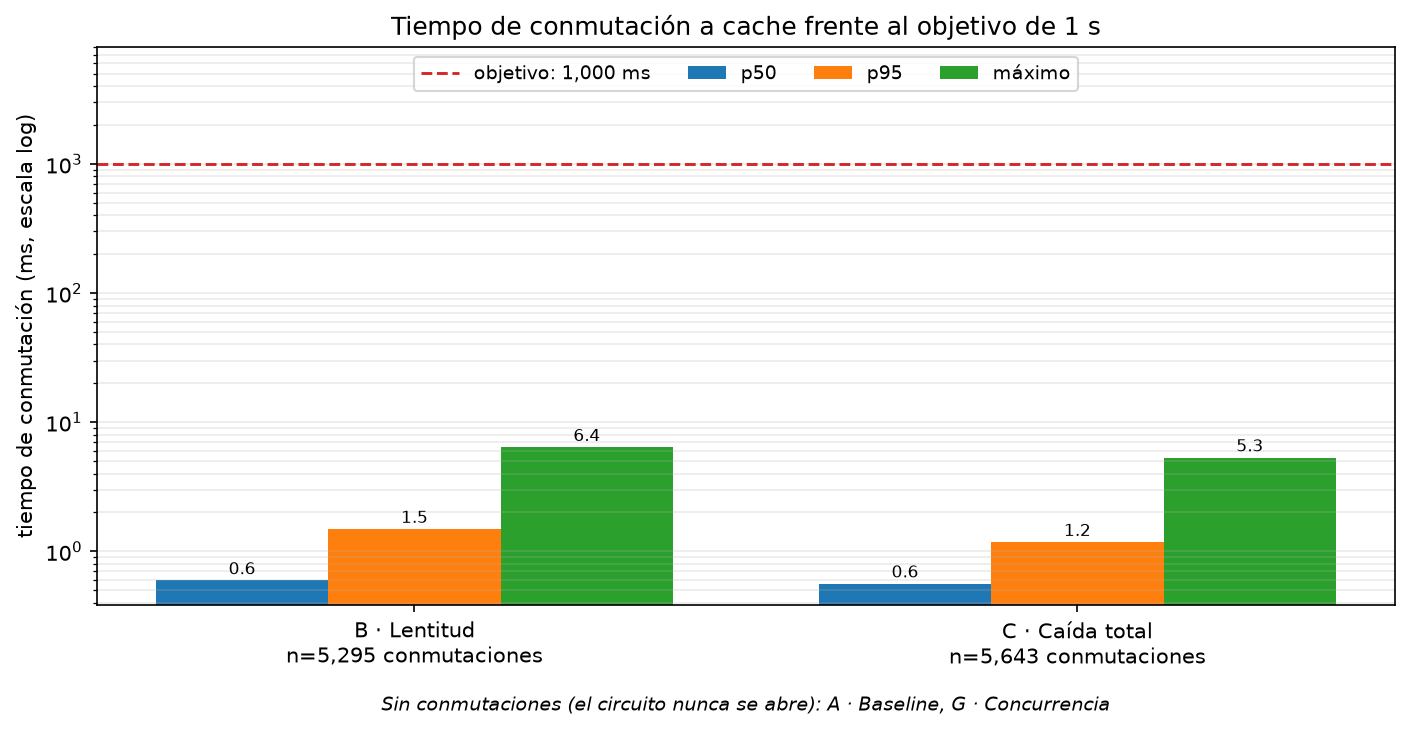

In [7]:
display(Image(filename=str(SALIDAS / "disponibilidad_por_escenario.png")))
display(Image(filename=str(SALIDAS / "conmutaciones_bajo_1s.png")))

Las cuatro barras de disponibilidad tocan el 100 % y quedan sobre la línea de meta del 99,9 %. No hubo ni un fallo en 18.217 peticiones.

La segunda gráfica muestra cuánto tardó la conmutación frente al objetivo de 1 s. En B la conmutación típica fue de 0,6 ms y la más lenta de todas llegó a 6,4 ms; en C, 0,6 ms y 5,3 ms. Incluso el peor caso queda unas 156 veces por debajo del límite, y por eso el 100 % de las conmutaciones cumple la meta. A y G no aparecen porque su circuito nunca se abrió: no hubo conmutaciones que medir.

Vale la pena separar dos cosas que suelen confundirse. Conmutar es barato, cuestión de milisegundos; lo caro es **detectar** que hay que hacerlo, y eso cuesta los 700 ms del timeout. Aun así, la petición más lenta de B llegó a 712,8 ms sumando detección y conmutación, todavía por debajo del segundo.

## 6. Throughput bajo concurrencia (escenario G)

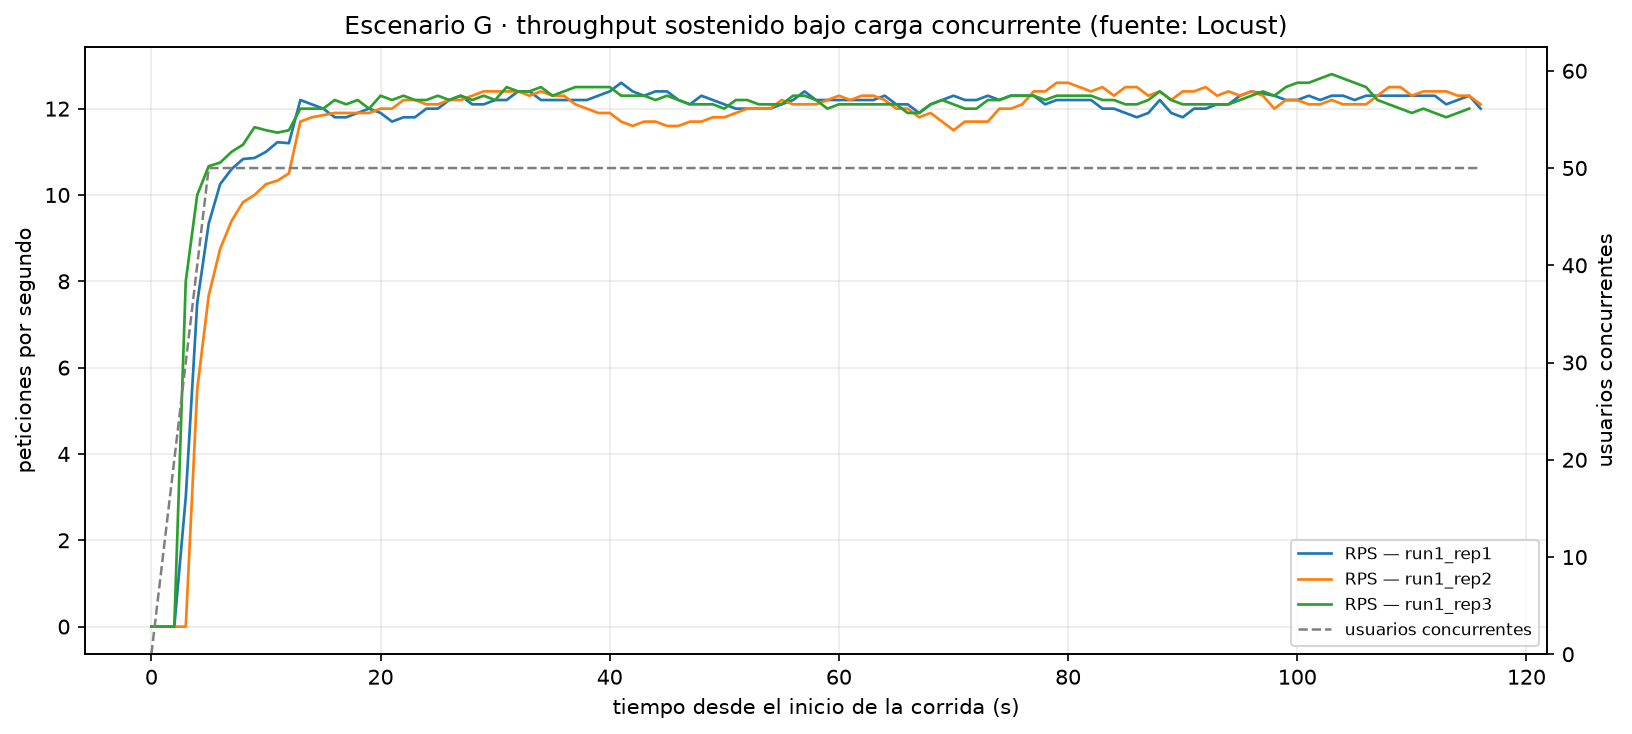

In [8]:
display(Image(filename=str(SALIDAS / "throughput_escenario_g.png")))

Este es el único dato que aportan los CSV de Locust. Los usuarios suben a 50 en los primeros segundos (línea gris) y el throughput se estabiliza en ~12 peticiones por segundo, sin caídas ni degradación progresiva durante los 120 s. Las tres corridas quedan prácticamente superpuestas.

El aporte de G, entonces, es mostrar que **la carga por sí sola no dispara el breaker**: 4.642 peticiones concurrentes sin una sola conmutación espuria. El circuito solo reacciona a degradación real del proveedor, que es el comportamiento deseado.

## 7. Consistencia entre corridas

In [9]:
repro = metricas.reproducibilidad(df)
repro[repro.escenario.isin(ESCENARIOS_ENTREGABLE)][
    ["escenario", "corridas", "disponibilidad_pct_std",
     "pct_conmutaciones_bajo_1s_std", "latencia_p50_ms_min", "latencia_p50_ms_max"]
].round(3)

,escenario,corridas,disponibilidad_pct_std,pct_conmutaciones_bajo_1s_std,latencia_p50_ms_min,latencia_p50_ms_max
0,A,3,0.0,NaN,494.357,502.305
1,B,3,0.0,0.0,0.716,0.733
2,C,3,0.0,0.0,0.685,0.696
6,G,3,0.0,NaN,3760.231,3800.737


Desviación estándar cero en disponibilidad y en el porcentaje bajo 1 s: las tres corridas de cada escenario dieron lo mismo. Las medianas de latencia también se mueven poco (en B, entre 0,716 y 0,733 ms). Los resultados no dependen de la corrida.

## Conclusiones

El ASR HA2 se cumple en los escenarios de este bloque. Con el proveedor degradado (lento en B, caído en C) el sistema mantuvo el 100 % de disponibilidad y conmutó a caché en milisegundos, muy lejos del límite de 1 s.

Tres cosas que conviene declarar al consolidar la evidencia:

1. **Falta el cruce entre degradación y concurrencia.** G corrió con el proveedor sano, así que ningún escenario probó qué pasa cuando el proveedor se degrada y hay carga alta al mismo tiempo.
2. **La disponibilidad del 100 % supone la caché poblada.** En B y C todas las peticiones derivadas encontraron perfil. El escenario F cubre el caso contrario.
3. **El registro interno tiene ~5 % más peticiones que Locust** (en A, 773 contra 708), porque el Adaptador registra peticiones fuera de la ventana de medición de Locust. No afecta a las métricas, que son proporciones, pero explica que los conteos no cuadren si se comparan las dos fuentes.

El análisis del costo diferenciado entre la petición que dispara el corte y las que encuentran el circuito ya abierto se aborda por separado; el motor de métricas ya expone ese desglose mediante `metricas.por_poblacion()`.

## Costo del disparo vs. circuito ya abierto (escenarios B, C y D)

### Descripción

`clasificar_poblacion()` (paquete `analisis.procesamiento.carga`) separa
cada petición en tres poblaciones de costo muy distinto — **TRIGGER** (dispara el corte),
**CIRCUITO_ABIERTO** (ya lo encuentra abierto) y **NORMAL** (circuito cerrado, proveedor
sano) — y toda métrica de latencia y conmutación se puede desglosar también por ellas.
Esta sección responde la pregunta que el resumen anterior deja pendiente: **¿cuánto
cuesta disparar el corte frente a encontrarlo ya abierto, y ese costo depende de qué lo
abrió?**

Para responderla se suma **D**, que no deja que el proveedor se degrade: fuerza el
breaker a `OPEN` *antes* de arrancar la medición y acota la corrida a 6 s (menor que los
10 s de `reset_timeout`) para que toda la ventana medida caiga con el circuito ya abierto.
B y C, en cambio, degradan el proveedor en vivo durante 60 s y dejan que el propio
tráfico dispare el corte. No hay fuentes nuevas que cargar ni cambios de esquema: se
reutilizan `df` y `RAIZ` de la celda de configuración inicial.

In [10]:
ESCENARIOS_BCD = ["B", "C", "D"]
condiciones[condiciones.escenario.isin(ESCENARIOS_BCD)].drop_duplicates(
    subset=["escenario", "modo_mock", "usuarios", "duracion_s"]
)[["escenario", "modo_mock", "usuarios", "duracion_s", "spawn_rate", "timeout_ms", "fail_max", "reset_timeout_s", "ttl_s"]]

,escenario,modo_mock,usuarios,duracion_s,spawn_rate,timeout_ms,fail_max,reset_timeout_s,ttl_s
3,B,lento,10,60,2.0,700,1,10,300
6,C,caido,10,60,2.0,700,1,10,300
9,D,normal,10,6,10.0,700,1,10,300


D comparte `fail_max`, `reset_timeout` y `timeout` con B y C — lo único que cambia es el
modo del proveedor (`normal`, porque D nunca lo degrada) y la carga: 6 s con
`spawn_rate=10` en vez de 60 s con `spawn_rate=2`, para que la ventana completa caiga
dentro del circuito ya abierto (ver `load-testing/README.md`, nota del escenario D).

### Estado del circuito en el tiempo

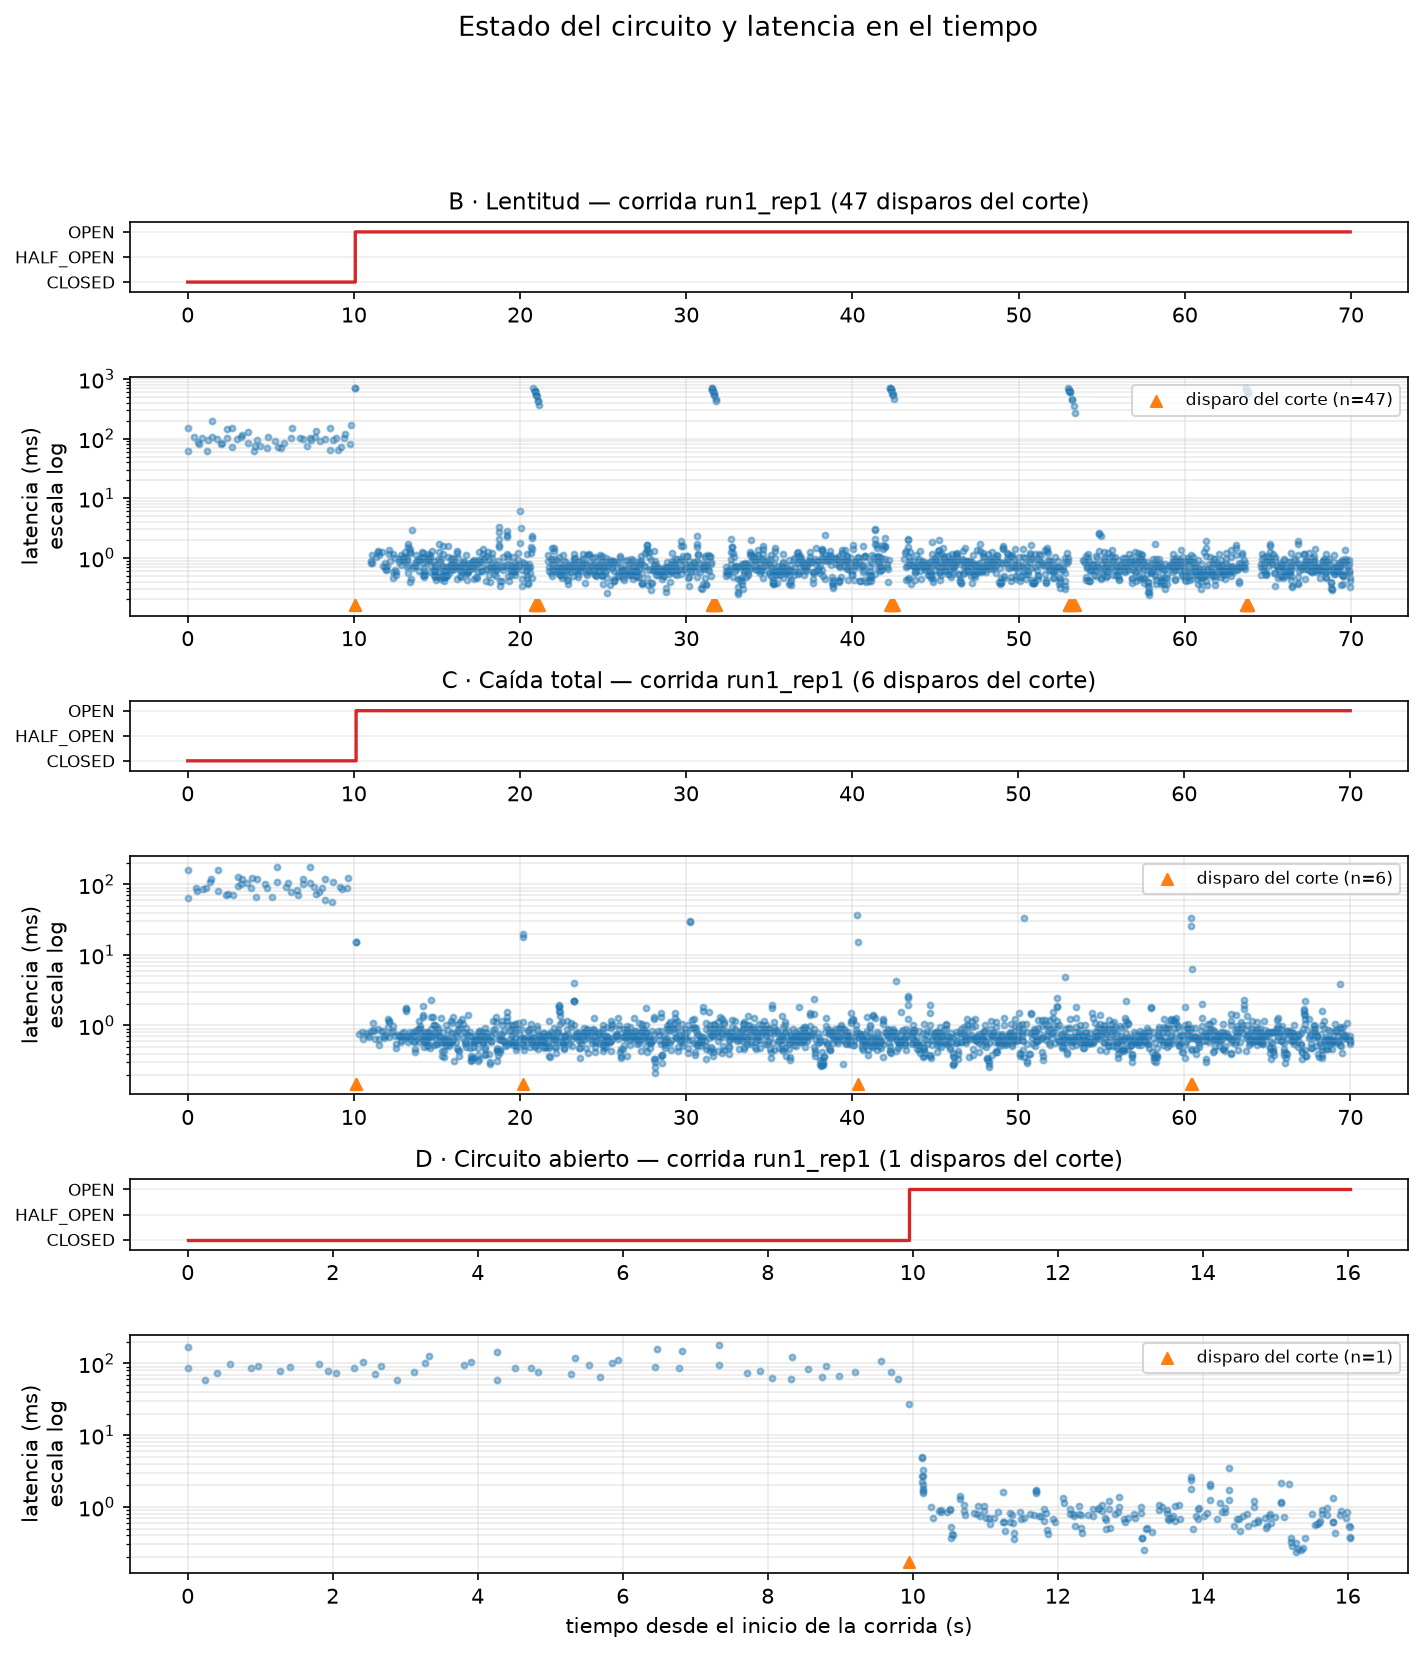

In [11]:
display(Image(filename=str(SALIDAS / "estado_circuito_y_latencia_bcd.png")))

Los tres paneles comparten el eje Y de latencia (log) pero no el de tiempo: B y C corren
60 s (nótese el eje hasta 70), D corre 6 s (eje hasta 16, contando el warm-up).

En B y C, el circuito abre a los ~10 s (fin del warm-up) y a partir de ahí la latencia se
desploma de ~100 ms a ~0,7 ms. Los triángulos que salpican el borde inferior después del
corte — 47 en B, 6 en C en esta corrida — son los reintentos `HALF_OPEN`, y los puntos
altos aislados que quedan por encima de la nube de 1 ms son esos mismos reintentos
pagando otra vez el costo completo de la falla.

El panel de D es distinto: también hay ~10 s de warm-up contra el proveedor sano (la
misma banda de ~100 ms que en B y C) y el mismo desplome al abrir, pero la corrida
termina a los 16 s — no le da tiempo a que aparezca un solo triángulo. Es la corrida más
limpia de las tres: aísla la población CIRCUITO_ABIERTO sin la fuga periódica que sí
contamina a B y, en menor medida, a C.

### Costo por población

In [12]:
poblaciones = metricas.por_poblacion(df)
columnas_poblacion = [
    "escenario", "poblacion", "peticiones", "pct_del_escenario",
    "latencia_p50_ms", "latencia_p95_ms", "latencia_max_ms",
    "conmutacion_p50_ms", "conmutacion_max_ms",
]
poblaciones[poblaciones.escenario.isin(ESCENARIOS_BCD)][columnas_poblacion].round(2)

,escenario,poblacion,peticiones,pct_del_escenario,latencia_p50_ms,latencia_p95_ms,latencia_max_ms,conmutacion_p50_ms,conmutacion_max_ms
1,B,CIRCUITO_ABIERTO,5158,94.66,0.71,1.38,712.81,0.59,6.11
2,B,NORMAL,154,2.83,94.78,154.06,195.05,NaN,NaN
3,B,TRIGGER,137,2.51,589.18,706.78,711.14,3.03,6.40
4,C,CIRCUITO_ABIERTO,5624,97.15,0.68,1.31,36.72,0.56,5.33
5,C,NORMAL,146,2.52,90.51,162.58,179.85,NaN,NaN
6,C,TRIGGER,19,0.33,15.52,26.43,31.26,0.87,2.03
7,D,CIRCUITO_ABIERTO,613,79.82,0.71,1.70,4.94,0.59,4.82
8,D,NORMAL,152,19.79,87.95,159.58,196.03,NaN,NaN
9,D,TRIGGER,3,0.39,34.34,36.02,36.20,0.49,0.65


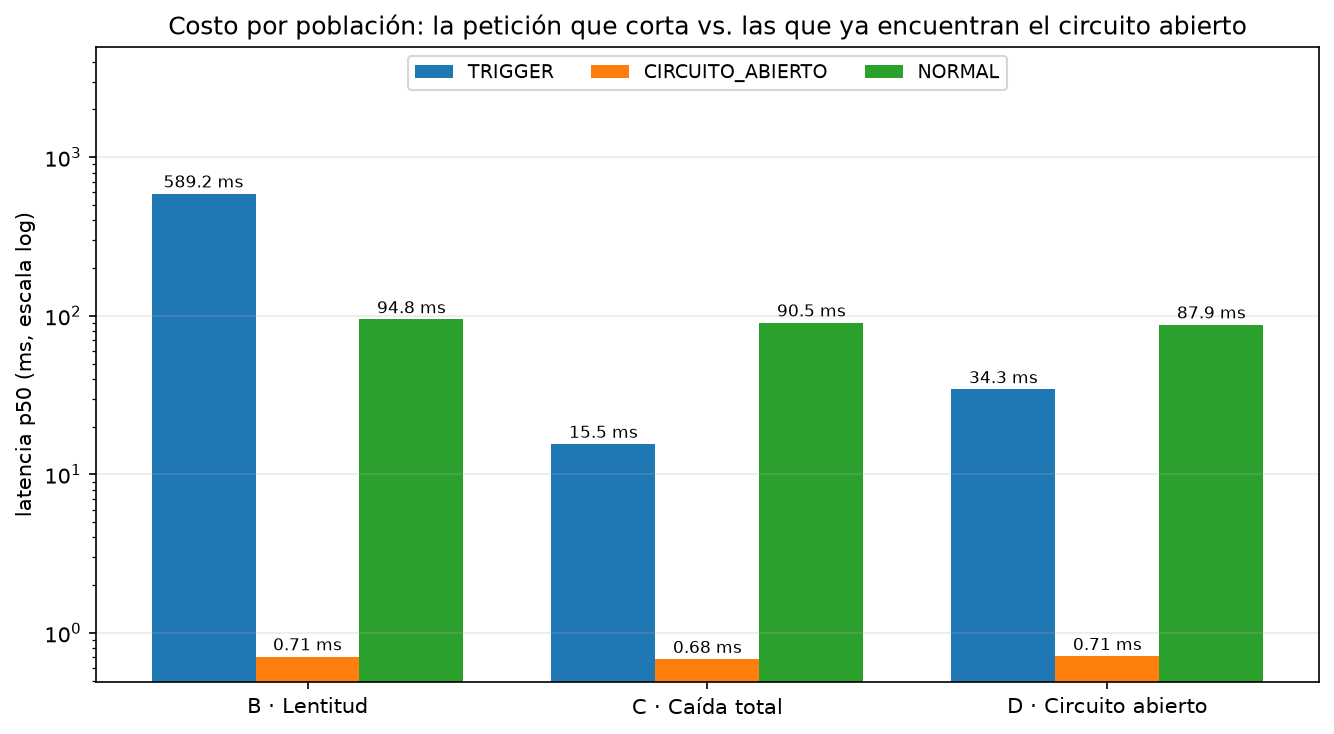

In [13]:
display(Image(filename=str(SALIDAS / "latencia_por_poblacion_bcd.png")))

La barra CIRCUITO_ABIERTO es prácticamente idéntica en los tres escenarios (0,71 / 0,68 /
0,71 ms): una vez que el breaker está `OPEN`, resolver desde Redis cuesta lo mismo sin
importar si lo abrió la lentitud, la caída total o una llamada forzada. La barra que sí se
mueve — dos órdenes de magnitud entre B y C, y otra vez entre C y D — es TRIGGER, y esa
diferencia no es del mecanismo sino del **modo de falla** que hay que detectar: esperar
un timeout de 700 ms cuesta 700 ms; que el proveedor rechace de inmediato cuesta
milisegundos.

Sobre `pct_del_escenario` de D: se calcula sobre **todo** lo que el Adaptador registró
bajo `escenario=D`, y eso incluye el warm-up descartable (152 peticiones NORMAL, contra
proveedor sano) y la propia llamada de preparación. Locust solo mide lo que viene
después: 613 CIRCUITO_ABIERTO + 3 TRIGGER = 616 peticiones, de las cuales el 99,5 % ya
encontró el circuito abierto. El 79,8 % que muestra la tabla no está mal — es la
proporción sobre el total logueado, warm-up incluido — pero el número que responde
"¿qué tan bien evita llamadas la ventana que Locust realmente midió?" es el 99,5 %, no
el 79,8 %.

**La TRIGGER de D tampoco es comparable en naturaleza con la de B/C.** Sus 3 peticiones
son una única llamada de preparación (`provocar_apertura_circuito`) que el harness
dispara *antes* de que arranque Locust, no tráfico concurrente real disparando el corte.
D no mide "cuánto cuesta disparar bajo carga"; aísla, a propósito, la población
CIRCUITO_ABIERTO.

### El disparo bajo concurrencia: por qué nunca es una sola petición

`fail_max=1` dice que basta una falla para abrir el circuito. Bajo carga concurrente eso
no significa que solo una petición pague el disparo: varias pueden leer el breaker como
`CLOSED` (o, en un reintento, como `HALF_OPEN`) antes de que cualquiera de ellas alcance
a tumbarlo, así que **todas** entran a `_consultar_open_finance` y **todas** terminan
marcadas como la transición hacia `OPEN`.

In [14]:
disparos = df[(df.poblacion == "TRIGGER") & (df.estado_circuito_inicio == "CLOSED")]
disparos = disparos[disparos.escenario.isin(ESCENARIOS_BCD)]
disparos.groupby(["escenario", "ejecucion_id"]).size().rename("disparos_simultaneos").reset_index()

,escenario,ejecucion_id,disparos_simultaneos
0,B,run1_rep1,2
1,B,run1_rep2,2
2,B,run1_rep3,2
3,C,run1_rep1,2
4,C,run1_rep2,2
5,C,run1_rep3,2
6,D,run1_rep1,1
7,D,run1_rep2,1
8,D,run1_rep3,1


Dos peticiones, en las 6 corridas de B y C, sin una sola excepción — y una sola en D, que
dispara con una llamada de preparación controlada, sin concurrencia. No es una corrida
puntual con mala suerte: con 10 usuarios y `spawn_rate=2` (o `10` en D), es sistemático.

Eso es solo el disparo inicial. Mientras el proveedor sigue degradado, el breaker vuelve
a probarlo cada `reset_timeout` (`HALF_OPEN`), y si la prueba también falla, ese reintento
*también* queda clasificado como TRIGGER porque también tumba el circuito a `OPEN`.
`metricas.desglose_trigger()` separa las dos cosas.

In [15]:
desglose = metricas.desglose_trigger(df)
desglose[desglose.escenario.isin(ESCENARIOS_BCD)].sort_values("escenario")

,escenario,disparo_inicial,reintentos_half_open,circuito_abierto,pct_fuga_reintentos
0,B,6,131,5158,2.476839
1,C,6,13,5624,0.230619
2,D,3,0,613,0.000000


En B, los 137 TRIGGER de la tabla anterior son 6 disparos iniciales (2 por corrida) más
**131 reintentos** — el circuito se reabre en promedio cada ~1,3 s de tráfico degradado.
En C son 6 más 13: el proveedor caído se detecta tan rápido (~15 ms) que hay muchas menos
oportunidades de que una petición caiga justo en la ventana `HALF_OPEN`. D no tiene
reintentos: su ventana de 6 s termina antes de que se cumpla el primer `reset_timeout` de
10 s.

### Llamadas evitadas: la fuga hacia el proveedor

"Circuito abierto" se lee como "cero llamadas al proveedor mientras dure la
degradación", pero eso es solo cierto entre reintentos. `pybreaker` prueba el proveedor
cada `reset_timeout`; si sigue caído, esa prueba falla, reabre el circuito y vuelve a
costar lo mismo que el disparo original. Esta gráfica mide qué fracción de la ventana
`OPEN` de cada escenario en realidad volvió a tocar al proveedor.

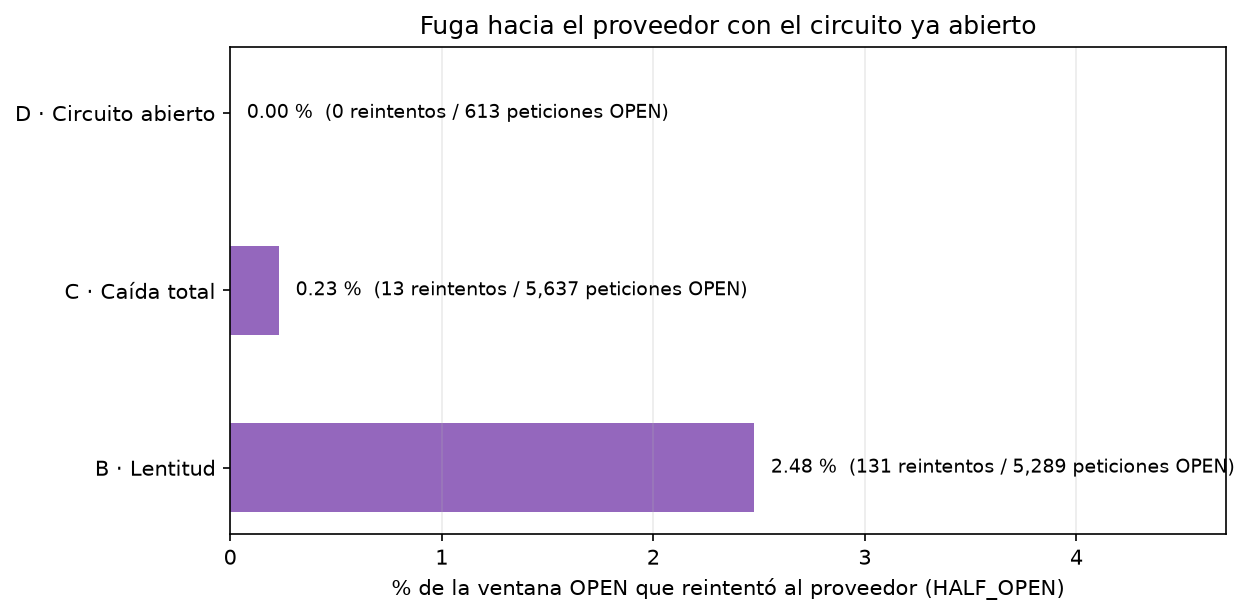

In [16]:
display(Image(filename=str(SALIDAS / "fuga_reintentos_bcd.png")))

B pierde 2,48 % de su ventana `OPEN` a reintentos que cuestan ~550 ms cada uno (el
timeout completo, otra vez); C pierde 0,23 %, porque un reintento fallido ahí solo
cuesta ~15 ms; D no pierde nada, pero no porque su circuito filtre menos, sino porque su
ventana medida (6 s) nunca llega al primer `reset_timeout` (10 s) — es una propiedad del
diseño del escenario, no del mecanismo. Extender la corrida de D más allá de 10 s debería
reproducir la misma fuga que ya se ve en B y C.

### Conclusiones

1. **El costo de "circuito abierto" no depende de qué lo abrió.** Lentitud, caída total o
   una apertura forzada llegan al mismo número: ~0,7 ms. La diferencia de dos órdenes de
   magnitud entre escenarios está toda en la población TRIGGER — 589 ms si hay que agotar
   el timeout (B) contra 15,5 ms si el proveedor rechaza de inmediato (C).
2. **El disparo bajo carga concurrente no es un evento de una sola petición.** Con
   `fail_max=1` y 10 usuarios simultáneos, siempre son exactamente 2 las peticiones que
   quedan marcadas como la transición a `OPEN`, en las 6 corridas de B y C sin excepción.
3. **"Circuito abierto" tiene una fuga medible hacia el proveedor.** Los reintentos
   `HALF_OPEN` devuelven hasta 2,48 % del tráfico al proveedor todavía caído (B). D no la
   muestra, pero solo porque su ventana de 6 s es más corta que `reset_timeout` (10 s) —
   no porque el mecanismo la evite mejor ahí.

## Recuperación del Circuit Breaker (escenario E)

### Descripción
Analizar únicamente E: identificar `OPEN → HALF_OPEN → CLOSED`, medir la recuperación
y verificar que las respuestas posteriores vuelven a Open Finance. Se comparan repeticiones
mediante tiempos en segundos, evidencias por petición, estadísticas descriptivas y tres gráficas.
La lógica reutilizable está en `analisis/procesamiento/recuperacion.py`; aquí se muestran los resultados.

**Entradas reales:** `results.csv`, `manifest.json`, `procedencia.json` e
`integridad.json` por corrida, complementados por las transiciones de `adaptador.jsonl`.
Los CSV `results_stats*` de Locust son agregados y no aportan estados ni fuentes por petición.
No hay insumos pendientes. Fuera de alcance: ejecutar experimentos, cambiar productores,
breaker, mock, Redis, instrumentación, manifests o almacenamiento, y analizar otros escenarios.

### Configuración y carga
Se reutilizan `RAIZ`, pandas y `display` de la celda inicial **Datos cargados**, como en los demás análisis.
Ejecutar primero esa celda de configuración; este bloque no añade cambios a `sys.path`.
La fuente analítica es real. Los fixtures sintéticos de `tests/test_recuperacion.py` solo prueban funciones.
Si faltan paquetes reales o tienen otra discrepancia de contenido, la carga falla explícitamente.
Los paquetes con hashes alterados exclusivamente por CRLF se aceptan con una advertencia visible:
**equivalencia de contenido no equivale a integridad estricta de los bytes del checkout**.

**Ejecución reproducible:** bloque y notebook completo verificados con Python 3.11, pandas 2.2.3,
NumPy 2.2.6 y Matplotlib 3.11.1 en un entorno aislado con kernel Jupyter. Seleccionar un kernel
con estas dependencias compatibles. El Python local original presenta una incompatibilidad binaria
Matplotlib/NumPy; no se modificaron sus paquetes ni las dependencias de los servicios.


In [10]:
from IPython.display import Markdown
import matplotlib.pyplot as plt
from analisis.procesamiento import recuperacion

resultados_e63 = RAIZ / "resultados"
raw_e63 = recuperacion.load_results(resultados_e63, resultados_e63 / "adaptador.jsonl")
display(Markdown(f"**DATOS: {raw_e63.label}** — {len(raw_e63.requests):,} peticiones; {len(raw_e63.manifests)} corridas."))

**DATOS: REALES** — 2,759 peticiones; 3 corridas.

### Validación y normalización
El mapeo queda centralizado: `ejecucion_id → corrida_id`, `ts_wall → timestamp` (UTC),
`estado_nuevo → estado_circuito`; `half-open → HALF_OPEN`. Se conservan los estados inicial/final.
Las fuentes reales son `PROVIDER`, `CACHE` y `NONE`; `OPEN_FINANCE` se admite como proveedor.
`N/A` en `hit_miss` significa que no se consultó caché; nunca se cuenta como MISS.

`timestamp_inicio/fin` son segundos **monotónicos**, no epoch. La aproximación
`ts_wall − (timestamp_fin − timestamp_inicio)` solo ayuda a asociar temporalmente peticiones
y transiciones; tiene el desfase del logging y no es un instante de entrada certificado.
Los tiempos de recuperación se calculan entre marcas UTC de **transiciones**, sin mezclar relojes.

Las transiciones históricas carecen de identidad: se asignan solo cuando pertenecen a una única
ventana observada de peticiones. Las identidades de otros escenarios se consultan únicamente
para detectar ambigüedad, sin calcular métricas de esos escenarios. Se preserva la preparación,
incluida la apertura anterior al manifest. Estas ventanas no se presentan como ventanas de Locust.

In [11]:
requests_e63, transitions_e63, conditions_e63, issues_e63 = recuperacion.normalize_results(raw_e63)
display(conditions_e63)
display(transitions_e63)
quality_e63 = pd.DataFrame(issues_e63).groupby("incidencia", sort=False).corrida_id.agg(lambda runs: ", ".join(sorted(set(runs)))).reset_index()
display(Markdown("**Calidad y procedencia:**\n\n" + "\n\n".join(
    f"- **{row.corrida_id}:** {row.incidencia}" for _, row in quality_e63.iterrows()
)))

,corrida_id,reset_timeout,fail_max,ttl,modo_mock,usuarios,duracion
0,run1_rep1,10,1,300,caido,10,60
1,run1_rep2,10,1,300,caido,10,60
2,run1_rep3,10,1,300,caido,10,60


,escenario,corrida_id,timestamp,estado_anterior,estado_circuito,asociacion
0,E,run1_rep1,2026-09-05 00:09:40.671855+00:00,CLOSED,OPEN,ventana observada única (asociación temporal)
1,E,run1_rep1,2026-09-05 00:09:50.704536+00:00,OPEN,HALF_OPEN,ventana observada única (asociación temporal)
2,E,run1_rep1,2026-09-05 00:09:50.810426+00:00,HALF_OPEN,CLOSED,ventana observada única (asociación temporal)
3,E,run1_rep2,2026-09-05 00:10:54.988209+00:00,CLOSED,OPEN,ventana observada única (asociación temporal)
4,E,run1_rep2,2026-09-05 00:11:05.006662+00:00,OPEN,HALF_OPEN,ventana observada única (asociación temporal)
5,E,run1_rep2,2026-09-05 00:11:05.115883+00:00,HALF_OPEN,CLOSED,ventana observada única (asociación temporal)
6,E,run1_rep3,2026-09-05 00:12:09.298491+00:00,CLOSED,OPEN,ventana observada única (asociación temporal)
7,E,run1_rep3,2026-09-05 00:12:19.315735+00:00,OPEN,HALF_OPEN,ventana observada única (asociación temporal)
8,E,run1_rep3,2026-09-05 00:12:19.411891+00:00,HALF_OPEN,CLOSED,ventana observada única (asociación temporal)


**Calidad y procedencia:**

- **run1_rep1, run1_rep2, run1_rep3:** procedencia.json: equivalencia CRLF→LF; integridad estricta del checkout NO confirmada

- **run1_rep1, run1_rep2, run1_rep3:** results.csv: equivalencia CRLF→LF; integridad estricta del checkout NO confirmada

- **run1_rep1, run1_rep2, run1_rep3:** Ventana de medición no confirmada: No se dispone de inicio y fin reales de medicion ni de una marca de fase por peticion. Se conservan todas las peticiones de la identidad, incluido posible warm-up y preparacion. El manifest se guarda antes de lanzar Locust y puede reutilizarse; su timestamp no certifica el inicio real. timestamp_inicio/fin del log son monotonicos; los Timestamp de stats_history son muestras, no limites de ejecucion. No se infiere el fin como timestamp del manifest mas duracion configurada. Ejecuciones distintas que reutilicen escenario y ejecucion_id no son distinguibles.

- **run1_rep1, run1_rep2, run1_rep3:** 1 peticiones: PROVIDER con proveedor_invocado=False (indicador derivado del estado inicial)

### Métricas y verificación del retorno
`t_open`, `t_half_open` y `t_closed` son marcas de **eventos registrados**. Se selecciona
la primera apertura observada, el primer `OPEN → HALF_OPEN` posterior y el primer
`HALF_OPEN → CLOSED` posterior a la apertura. Sin evidencia explícita, el instante queda `NaT`.
Los intervalos faltantes quedan `NaN`, nunca cero. Si hay reintentos, el intervalo HALF_OPEN→CLOSED
incluye el tiempo de esos intentos y se reportan sus conteos; no representa una sola llamada.

- OPEN→HALF_OPEN = `t_half_open − t_open`.
- HALF_OPEN→CLOSED = `t_closed − t_half_open`.
- Recuperación total = `t_closed − t_open`.
- Delta del timeout = OPEN→HALF_OPEN menos `circuit_breaker.reset_timeout_seconds` del manifest.

La prueba del proveedor se identifica por una petición exitosa `PROVIDER`, con estado final CLOSED,
intervalo compatible con HALF_OPEN/cierre y estado inicial OPEN o HALF_OPEN. La asociación es temporal,
no una correlación exacta por request_id en este histórico. Las respuestas posteriores deben **empezar
después de terminar esa petición de cierre**, comparando marcas del mismo reloj monotónico; así se
excluyen peticiones en vuelo. Se informa la duración de la observación posterior, no una garantía futura.

**Sí:** las cinco evidencias están presentes, todas las respuestas posteriores son exitosas del
proveedor y no se observan reaperturas posteriores. **No:** se observa caché, ausencia de respuesta
(`NONE`), fallo o reapertura después del cierre. **No determinable:** falta evidencia necesaria o
hay datos desconocidos. El indicador `proveedor_invocado` contradictorio se expone y no sustituye
la evidencia directa de `fuente_respuesta`. La ausencia de datos nunca es éxito.

In [12]:
summary_e63, evidence_e63, statistics_e63 = recuperacion.build_summary(
    requests_e63, transitions_e63, conditions_e63,
)

### Comparación entre corridas
Todos los intervalos, el timeout y su delta están en **segundos**. `NaT` y `NaN` significan
no determinable. La desviación estándar es muestral (`ddof=1`), indefinida con menos de dos valores.
La configuración se toma del manifest de cada repetición, no del `.env` actual.

In [13]:
with pd.option_context("display.max_columns", None, "display.max_colwidth", 120):
    display(summary_e63.round(6))
    display(evidence_e63)
    display(statistics_e63.round(6))

,corrida_id,t_open,t_half_open,t_closed,tiempo_open_a_half_open,tiempo_half_open_a_closed,tiempo_recuperacion_total,reset_timeout,delta_reset_timeout,intentos_half_open,reaperturas_antes_cierre,reaperturas_despues_cierre,retorno_open_finance_confirmado
0,run1_rep1,2026-09-05 00:09:40.671855+00:00,2026-09-05 00:09:50.704536+00:00,2026-09-05 00:09:50.810426+00:00,10.032681,0.105890,10.138571,10.0,0.032681,1,0,0,Sí
1,run1_rep2,2026-09-05 00:10:54.988209+00:00,2026-09-05 00:11:05.006662+00:00,2026-09-05 00:11:05.115883+00:00,10.018453,0.109221,10.127674,10.0,0.018453,1,0,0,Sí
2,run1_rep3,2026-09-05 00:12:09.298491+00:00,2026-09-05 00:12:19.315735+00:00,2026-09-05 00:12:19.411891+00:00,10.017244,0.096156,10.113400,10.0,0.017244,1,0,0,Sí


,corrida_id,cache_durante_open,half_open_observado,prueba_proveedor,closed_observado,proveedor_despues_closed,request_id_prueba,cache_en_open,peticiones_posteriores,provider_posterior,cache_posterior,none_posterior,fuente_desconocida_posterior,peticiones_sin_inicio_para_clasificar,observacion_posterior_s,retorno_open_finance_confirmado,motivo
0,run1_rep1,True,True,True,True,True,2f31c502-739c-42a9-b4d4-b0be87a4fd1d,259,606,606,0,0,0,0,50.311718,Sí,Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor
1,run1_rep2,True,True,True,True,True,13800341-3eac-41b9-90fd-2abff0ec1aa8,256,615,615,0,0,0,0,50.313770,Sí,Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor
2,run1_rep3,True,True,True,True,True,2afbeaa7-c448-4f6c-9716-6dd7c0baabe4,259,608,608,0,0,0,0,50.527711,Sí,Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor


,corridas_totales,valores_validos,promedio_s,minimo_s,maximo_s,desviacion_estandar_s
intervalo,,,,,,
tiempo_open_a_half_open,3,3,10.022793,10.017244,10.032681,0.008585
tiempo_half_open_a_closed,3,3,0.103756,0.096156,0.109221,0.006789
tiempo_recuperacion_total,3,3,10.126548,10.113400,10.138571,0.012623


### Gráficas
Cada panel representa una corrida; tiempo relativo a su primera apertura, conservando la
preparación en las fuentes de respuesta. Los estados provienen de eventos, las fuentes de
peticiones. No se dibuja HALF_OPEN si no está registrado. Las marcas verticales separadas y
el recuadro ampliado permiten ver el intervalo breve de prueba. No se exportan CSV ni PNG al repo.

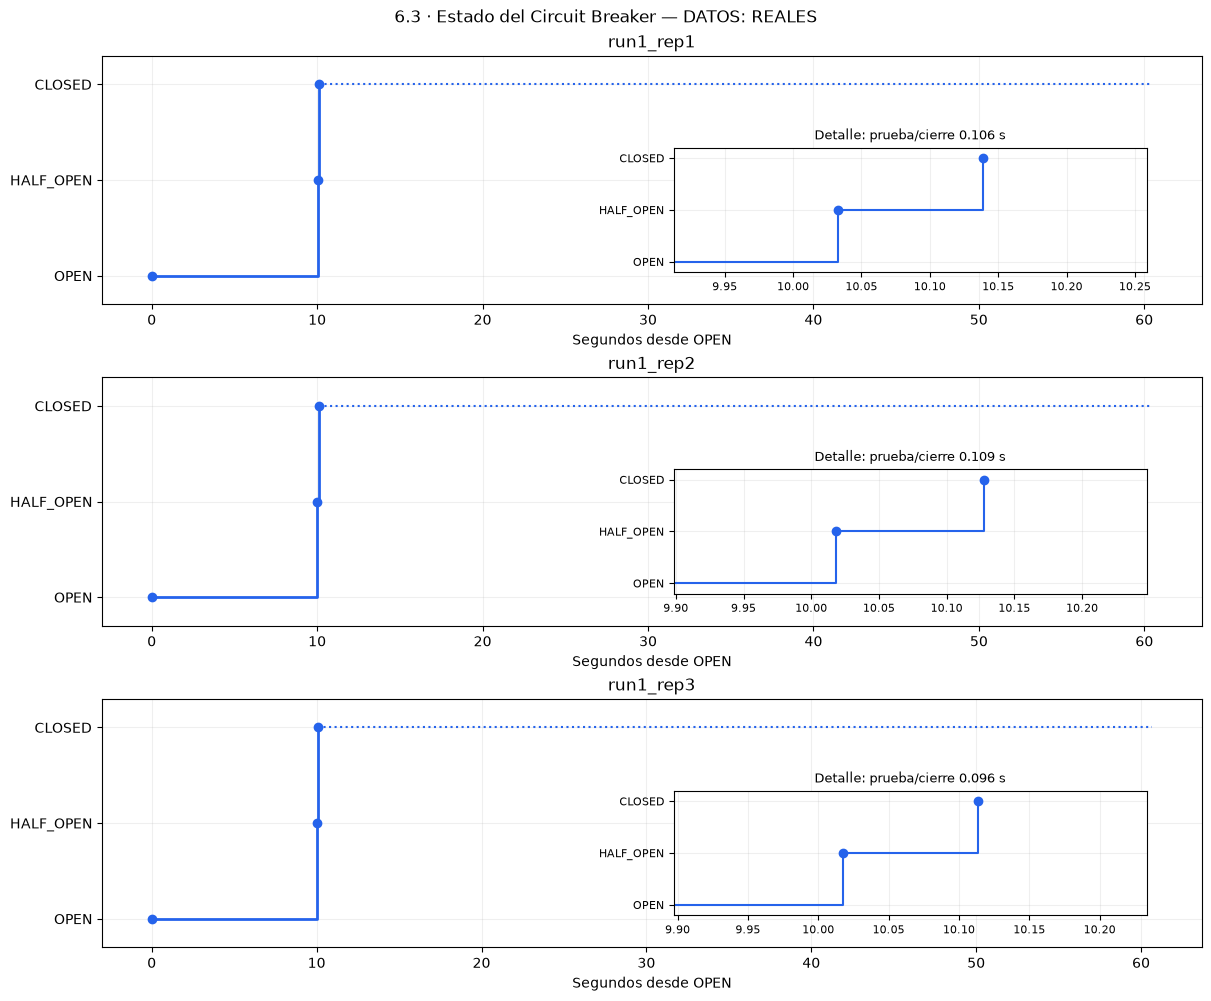

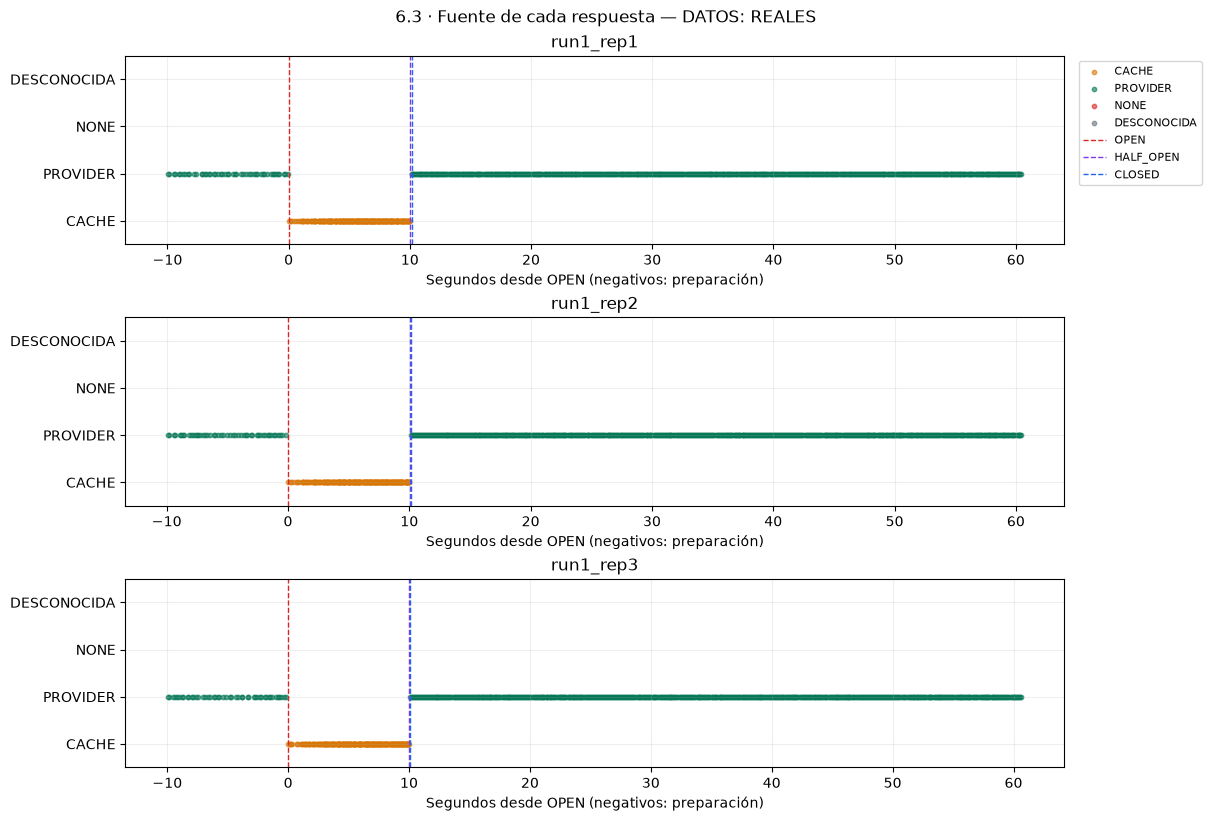

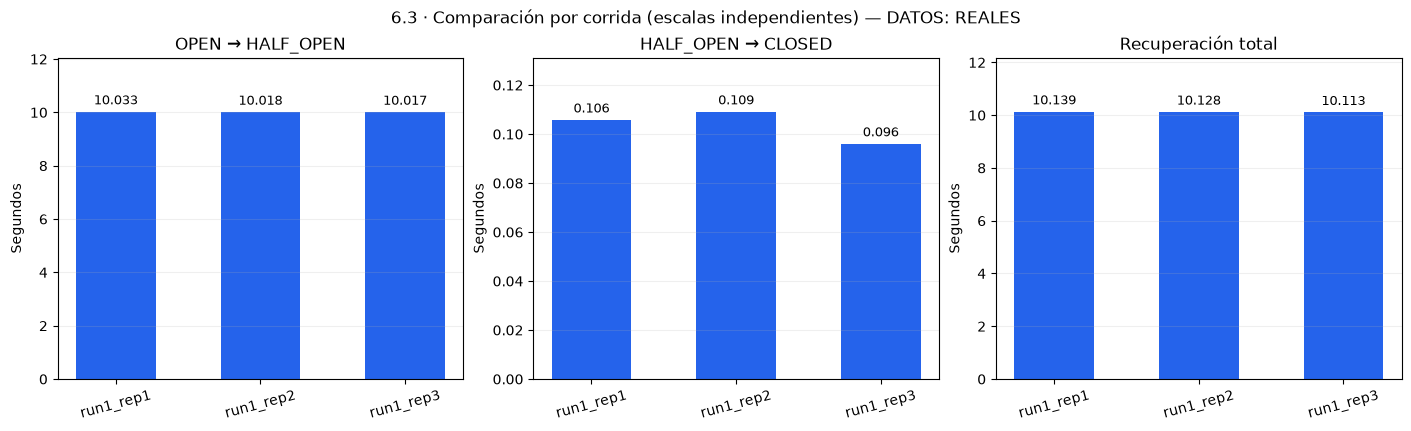

In [14]:
for figura_e63 in recuperacion.plot_recovery(requests_e63, transitions_e63, summary_e63, raw_e63.label):
    display(figura_e63)
    plt.close(figura_e63)

### Validación del pipeline

Los fixtures sintéticos y asserts están en `tests/test_recuperacion.py`. Cubren tres corridas completas,
tiempos, retorno al proveedor, cierre/HALF_OPEN/timeout ausentes, caché posterior, ausencia de tráfico
posterior, asociación ambigua, booleanos CSV, hashes y timestamps inválidos.

Desde la raíz, con las dependencias de análisis: `python -m unittest tests.test_recuperacion -v`.
Son pruebas del pipeline; sus datos no se mezclan con las tablas ni gráficas reales de este reporte.


### Conclusiones
Las conclusiones siguientes se regeneran desde las tablas anteriores. Los tiempos corresponden
al registro observado, no al instante de reparación del mock, que el manifest no registra.
Un delta positivo respecto al timeout describe la espera observada hasta la prueba bajo ese tráfico;
no demuestra un cambio de configuración ni establece por sí solo incumplimiento.

In [15]:
display(Markdown(recuperacion.recovery_conclusions(
    summary_e63, evidence_e63, statistics_e63, issues_e63, raw_e63.label,
)))

**DATOS: REALES.** Se analizaron **3 corridas** del escenario E; 3 tienen recuperación total medible.

La recuperación total media fue **10.126548 s**, con rango **10.113400–10.138571 s**. La desviación estándar muestral fue **0.012623 s**.

OPEN→HALF_OPEN: promedio **10.022793 s** en 3 corridas válidas.

HALF_OPEN→CLOSED: promedio **0.103756 s** en 3 corridas válidas.

Se pudo contrastar el timeout del manifest en **3 corridas**. El delta OPEN→HALF_OPEN − reset_timeout va de **0.017244 a 0.032681 s**.

Retorno a Open Finance confirmado en **3/3 corridas**, limitado al intervalo observado y a la asociación de eventos documentada.

- **run1_rep1: Sí**. Caché durante OPEN: 259; posteriores: 606 PROVIDER, 0 CACHE, 0 NONE y 0 de fuente desconocida. Observación posterior: 50.312 s. Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor.

- **run1_rep2: Sí**. Caché durante OPEN: 256; posteriores: 615 PROVIDER, 0 CACHE, 0 NONE y 0 de fuente desconocida. Observación posterior: 50.314 s. Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor.

- **run1_rep3: Sí**. Caché durante OPEN: 259; posteriores: 608 PROVIDER, 0 CACHE, 0 NONE y 0 de fuente desconocida. Observación posterior: 50.528 s. Cinco evidencias presentes; todas las peticiones posteriores observadas son exitosas del proveedor.

**Anomalías y límites:** 0 corridas con secuencia incompleta; 0 reaperturas antes del cierre y 0 después. La tabla de calidad conserva 12 incidencias de entrada. Incluye, cuando aparecen, equivalencia CRLF en lugar de integridad estricta, ventana de medición no certificada e inconsistencias de proveedor_invocado. Los eventos se asocian temporalmente cuando no tienen identificadores. No se certifica una única llamada concurrente de prueba ni se calcula tiempo desde la reparación efectiva del mock. La baja variabilidad descriptiva no prueba generalización.